<a href="https://colab.research.google.com/github/karthikkavali7/NLP/blob/main/Lab_12_Random_Forest_Implementation_Using_Random_Forest_from_libraries_and_comparing_results_with_AdaBoost_and_single_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/titanic_train.csv')

print('First 5 rows of the dataset:')
display(df.head())


First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Handling Missing Values in 'Age'

First, let's check for missing values in the 'Age' column and then fill them. A common strategy for numerical features like 'Age' is to fill missing values with the median, as it is less sensitive to outliers than the mean.



In [10]:
print('\nMissing values before handling:')
display(df.isnull().sum())

# Fill missing 'Age' values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

print('\nMissing values after handling Age:')
display(df.isnull().sum())


Missing values before handling:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0



Missing values after handling Age:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Encoding Categorical Features (Sex, Embarked)

**What are Categorical Features?**

Categorical features are variables that represent discrete categories or labels rather than continuous numerical values. For example:
*   **'Sex'**: Has two categories: 'male' and 'female'.
*   **'Embarked'**: Represents the port of embarkation, with categories like 'S' (Southampton), 'C' (Cherbourg), and 'Q' (Queenstown).

**Why do we need to encode them?**

Machine learning algorithms typically work with numerical input. They cannot directly process text labels like 'male' or 'female'. Encoding converts these categorical labels into a numerical format that the algorithms can understand and use.

**How to encode them?**

One common and effective method is **One-Hot Encoding**. This method creates new binary (0 or 1) columns for each category within a feature. For example, for 'Sex':
*   It would create two new columns: `Sex_female` and `Sex_male`.
*   If a person is female, `Sex_female` would be 1 and `Sex_male` would be 0.
*   If a person is male, `Sex_male` would be 1 and `Sex_female` would be 0.

This approach avoids implying any ordinal relationship (e.g., 'male' is greater than 'female') which doesn't exist. We'll use `pd.get_dummies` for this.

### Preparing Data for Model Training

First, we need to separate our dataset into **features (X)**, which are the input variables used to predict, and the **target variable (y)**, which is what we want to predict ('Survived' in this case). Then, we will split this data into training and testing sets. This allows us to train our models on one part of the data and evaluate their performance on unseen data.

In [17]:
from sklearn.model_selection import train_test_split

# --- Ensure df is fully preprocessed before defining X and y ---
# Fill missing 'Age' values with the median (if not already done)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Handle missing values in 'Embarked' by filling with the most frequent value (mode)
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Perform One-Hot Encoding for 'Sex' and 'Embarked' (if they still exist as columns)
cols_to_encode = [col for col in ['Sex', 'Embarked'] if col in df.columns]
if cols_to_encode:
    df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
# --- End preprocessing block ---

# Define features (X) and target (y)
# We'll drop 'PassengerId', 'Survived', 'Name', 'Ticket', and 'Cabin' as they are not typically used for direct prediction
X = df.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'], axis=1)
y = df['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print("\nFeatures (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Training set size: 712 samples
Testing set size: 179 samples

Features (X) head:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True



Target (y) head:


,Survived
0,0
1,1
2,1
3,1
4,0


### 1. Decision Tree Classifier

A Decision Tree builds a model of decisions and their possible consequences in a tree-like structure. It makes predictions by traversing the tree from the root to a leaf node.

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dtc = dtc.predict(X_test)

# Evaluate the model
print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dtc):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dtc))

Decision Tree Classifier Performance:
Accuracy: 0.7821
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.73      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179



### 2. AdaBoost Classifier

AdaBoost (Adaptive Boosting) is an ensemble method that combines multiple weak learners (e.g., shallow decision trees) to create a strong learner. It works by sequentially training models, with each new model focusing more on the samples that previous models misclassified.

In [19]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize and train the AdaBoost Classifier
# Using a Decision Tree as the base estimator
abc = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42)
abc.fit(X_train, y_train)

# Make predictions on the test set
y_pred_abc = abc.predict(X_test)

# Evaluate the model
print("AdaBoost Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_abc):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_abc))

AdaBoost Classifier Performance:
Accuracy: 0.7933
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       105
           1       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179



### 3. Random Forest Classifier

Random Forest is another ensemble learning method that builds multiple decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It's known for its high accuracy and ability to handle complex datasets.

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rfc = rfc.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rfc):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rfc))

Random Forest Classifier Performance:
Accuracy: 0.8212
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



### 4. Plotting Confusion Matrices

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. We will plot a confusion matrix for each of our trained models.

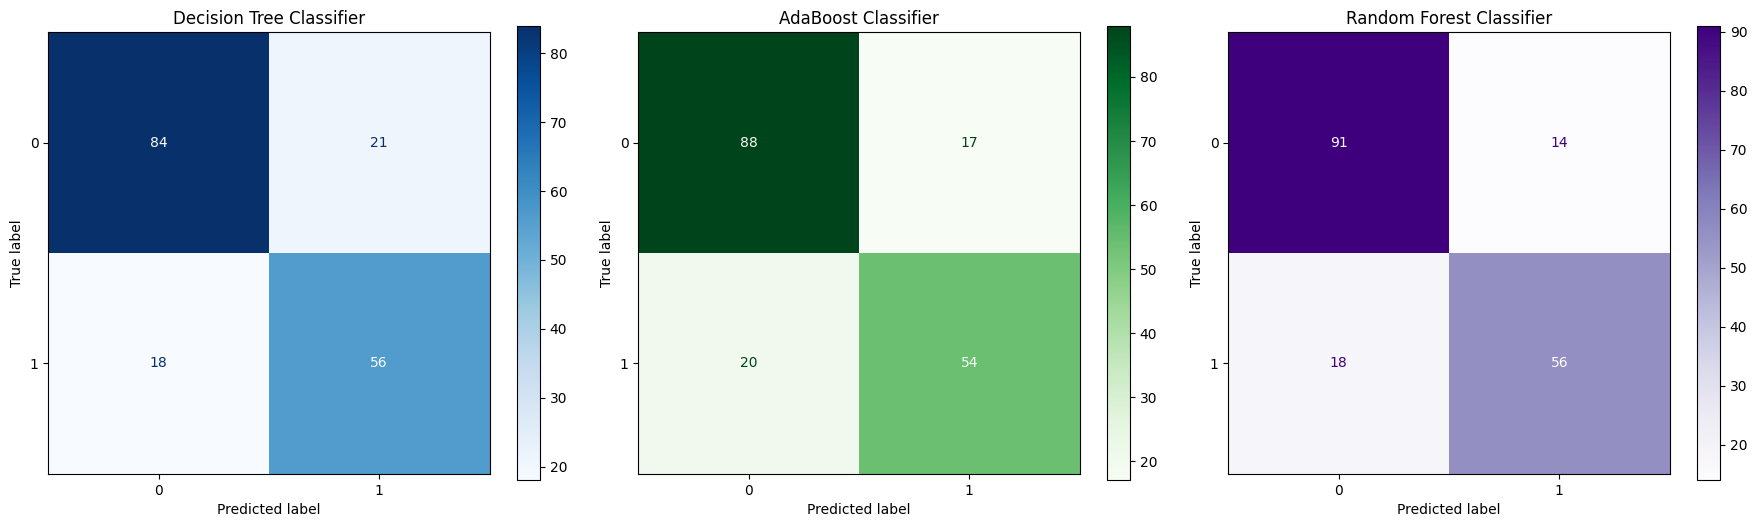

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# --- Decision Tree Classifier Confusion Matrix ---
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_estimator(dtc, X_test, y_test, cmap=plt.cm.Blues, ax=ax[0])
ax[0].set_title('Decision Tree Classifier')

# --- AdaBoost Classifier Confusion Matrix ---
ConfusionMatrixDisplay.from_estimator(abc, X_test, y_test, cmap=plt.cm.Greens, ax=ax[1])
ax[1].set_title('AdaBoost Classifier')

# --- Random Forest Classifier Confusion Matrix ---
ConfusionMatrixDisplay.from_estimator(rfc, X_test, y_test, cmap=plt.cm.Purples, ax=ax[2])
ax[2].set_title('Random Forest Classifier')

plt.tight_layout()
plt.show()

### 5. Identifying the Best Performing Ensemble Method

Based on the accuracy scores and classification reports obtained previously:

*   **Decision Tree Classifier Accuracy:** 0.7821
*   **AdaBoost Classifier Accuracy:** 0.7933
*   **Random Forest Classifier Accuracy:** 0.8212

The **Random Forest Classifier** demonstrated the best performance with an accuracy of **0.8212** on the test set. It had a good balance of precision and recall for both classes (0 and 1), and its overall accuracy was higher than both the individual Decision Tree and the AdaBoost ensemble. This indicates that combining multiple decision trees (the 'forest') and averaging their predictions helped reduce overfitting and improved the model's generalization capability compared to a single decision tree or an AdaBoost model with shallow trees.

In [7]:
# Check if 'Embarked' column exists before trying to fill missing values
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Prepare a list of categorical columns that still exist in the DataFrame for one-hot encoding
cols_to_encode = [col for col in ['Sex', 'Embarked'] if col in df.columns]

# Perform One-Hot Encoding only if there are columns to encode
if cols_to_encode:
    df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

print('\nFirst 5 rows after encoding categorical features:')
display(df.head())


First 5 rows after encoding categorical features:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,True,False,True
